# Notebook 9 — Entanglement-Growth Analysis

This notebook tests a second physical mechanism: whether the architectures that develop entanglement faster also exhibit earlier \(\tau_{BP}\).

Unlike Notebook 8, this **does require fresh quantum simulation**, because entanglement must be measured from the actual quantum state. It does not use `variance_curves.csv` for the entanglement measurements.

The experiment keeps the same ansatz structure and architecture schedules as Notebook 7, uses fresh random parameters, measures bipartite von Neumann entropy, and then compares its growth against the already-measured \(\tau_{BP}\).

---


## Cell 1 — Setup


In [1]:
# ============================================================
# NOTEBOOK 9 — ENTANGLEMENT-GROWTH ANALYSIS
# ============================================================
#
# Scientific question:
#
#   Do architectures that generate entanglement more rapidly
#   also exhibit earlier finite-depth barren-plateau onset?
#
# Architectures:
#   1. 1D Brick-Wall
#   2. 2D Rectangular Grid
#   3. All-to-All
#
# This is a NEW simulation.
#
# It does NOT use variance_curves.csv to calculate entropy.
#
# The previously measured architecture tau_BP values are used
# only to locate the BP onset relative to entanglement growth.
#
# ============================================================

%pip install -q pennylane "numpy<2"

import os
import time
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from scipy.stats import spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# ------------------------------------------------------------
# Core protocol
# ------------------------------------------------------------

N_SAMPLES = 50
MAX_DEPTH = 30

# Same system sizes and k grid used for architecture study.
N_VALUES = [8, 10, 12, 14]

K_BY_N = {
    8:  [2, 3, 4, 5, 6, 8],
    10: [2, 3, 4, 5, 6, 8, 10],
    12: [2, 3, 4, 5, 6, 8, 10, 12],
    14: [2, 3, 4, 5, 6, 8, 10, 12, 14],
}

ARCHITECTURES = [
    "brickwall_1d",
    "grid_2d",
    "all_to_all",
]

MASTER_SEED = 20260903

# Previous architecture experiment's tau_BP values.
TAU_FILE = "architecture_tau.csv"
if not os.path.exists(TAU_FILE):
    alt_path = os.path.join("notebook7_architecture_generalization", "architecture_tau.csv")
    if os.path.exists(alt_path):
        TAU_FILE = alt_path

# ------------------------------------------------------------
# Grid geometry
# ------------------------------------------------------------

GRID_SHAPES = {
    8:  (2, 4),
    10: (2, 5),
    12: (3, 4),
    14: (2, 7),
}

# ------------------------------------------------------------
# Output/checkpoints
# ------------------------------------------------------------

OUTPUT_DIR = "notebook9_entanglement_growth"

CHECKPOINT_DIR = os.path.join(
    OUTPUT_DIR,
    "checkpoints"
)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

CHECKPOINT_FILE = os.path.join(
    CHECKPOINT_DIR,
    "entanglement_checkpoint.pkl"
)

RAW_OUTPUT = os.path.join(
    OUTPUT_DIR,
    "entanglement_raw.csv"
)

SUMMARY_OUTPUT = os.path.join(
    OUTPUT_DIR,
    "entanglement_summary.csv"
)

TAU_ENTANGLEMENT_OUTPUT = os.path.join(
    OUTPUT_DIR,
    "tau_entanglement_metrics.csv"
)

print("=" * 80)
print("NOTEBOOK 9 — ENTANGLEMENT-GROWTH ANALYSIS")
print("=" * 80)
print("PennyLane:", qml.__version__)
print("Samples:", N_SAMPLES)
print("Max depth:", MAX_DEPTH)
print("Architectures:", ARCHITECTURES)
print("n values:", N_VALUES)
print("Master seed:", MASTER_SEED)
print("=" * 80)

Note: you may need to restart the kernel to use updated packages.
NOTEBOOK 9 — ENTANGLEMENT-GROWTH ANALYSIS
PennyLane: 0.44.1
Samples: 50
Max depth: 30
Architectures: ['brickwall_1d', 'grid_2d', 'all_to_all']
n values: [8, 10, 12, 14]
Master seed: 20260903


c:\Users\Abhishek\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


---


## Cell 2 — Simulator


In [2]:
# ============================================================
# CELL 2 — STATEVECTOR SIMULATOR
# ============================================================

try:

    test_device = qml.device(
        "lightning.qubit",
        wires=2
    )

    SIMULATOR = "lightning.qubit"

except Exception:

    SIMULATOR = "default.qubit"

print(
    "Simulator:",
    SIMULATOR
)

print(
    "Statevector access is required for entropy calculation."
)

Simulator: lightning.qubit
Statevector access is required for entropy calculation.


---


## Cell 3 — Reconstruct the exact architecture schedules


In [3]:
# ============================================================
# CELL 3 — ARCHITECTURE SCHEDULES
# ============================================================
#
# These reproduce the connectivity definitions used in
# Notebook 7.
#
# Entanglement analysis must use the same circuit architecture.
# ============================================================

def brickwall_pairs(
    n,
    layer
):

    if layer % 2 == 0:

        return [
            (q, q + 1)
            for q in range(
                0,
                n - 1,
                2
            )
        ]

    return [
        (q, q + 1)
        for q in range(
            1,
            n - 1,
            2
        )
    ]


def grid_edges(
    n
):

    if n not in GRID_SHAPES:
        raise ValueError(
            f"No grid shape defined for n={n}"
        )

    rows, cols = GRID_SHAPES[n]

    edges = []

    # Horizontal edges
    for r in range(rows):

        for c in range(cols - 1):

            q1 = r * cols + c
            q2 = r * cols + c + 1

            edges.append(
                (q1, q2)
            )

    # Vertical edges
    for r in range(rows - 1):

        for c in range(cols):

            q1 = r * cols + c
            q2 = (r + 1) * cols + c

            edges.append(
                (q1, q2)
            )

    return edges


def greedy_matchings(
    edges
):

    remaining = list(edges)
    matchings = []

    while remaining:

        used = set()
        current = []
        leftover = []

        for q1, q2 in remaining:

            if (
                q1 not in used
                and q2 not in used
            ):

                current.append(
                    (q1, q2)
                )

                used.add(q1)
                used.add(q2)

            else:

                leftover.append(
                    (q1, q2)
                )

        matchings.append(
            current
        )

        remaining = leftover

    return matchings


GRID_MATCHINGS = {
    n: greedy_matchings(
        grid_edges(n)
    )
    for n in GRID_SHAPES
}


def round_robin_matchings(
    n
):

    nodes = list(
        range(n)
    )

    if n % 2 == 1:
        nodes.append(None)

    fixed = nodes[-1]
    rotating = nodes[:-1]

    rounds = len(nodes) - 1

    matchings = []

    for _ in range(rounds):

        current = [
            fixed
        ] + rotating

        pairs = []

        for i in range(
            len(current) // 2
        ):

            a = current[i]
            b = current[-1 - i]

            if (
                a is not None
                and b is not None
            ):

                pairs.append(
                    (a, b)
                )

        matchings.append(
            pairs
        )

        rotating = (
            [rotating[-1]]
            + rotating[:-1]
        )

    return matchings


def architecture_pairs(
    architecture,
    n,
    layer
):

    if architecture == "brickwall_1d":

        return brickwall_pairs(
            n,
            layer
        )

    if architecture == "grid_2d":

        matchings = GRID_MATCHINGS[n]

        return matchings[
            layer % len(matchings)
        ]

    if architecture == "all_to_all":

        matchings = round_robin_matchings(n)

        return matchings[
            layer % len(matchings)
        ]

    raise ValueError(
        f"Unknown architecture: {architecture}"
    )

---


## Cell 4 — Verify schedules


In [4]:
# ============================================================
# CELL 4 — CONNECTIVITY SANITY CHECK
# ============================================================

def is_valid_matching(
    pairs
):

    used = set()

    for q1, q2 in pairs:

        if q1 == q2:
            return False

        if q1 in used or q2 in used:
            return False

        used.add(q1)
        used.add(q2)

    return True


for architecture in ARCHITECTURES:

    for n in N_VALUES:

        for layer in range(6):

            pairs = architecture_pairs(
                architecture,
                n,
                layer
            )

            if not is_valid_matching(
                pairs
            ):

                raise RuntimeError(
                    f"Invalid matching: "
                    f"{architecture}, n={n}, layer={layer}"
                )

print(
    "PASS: All architecture schedules are valid."
)

PASS: All architecture schedules are valid.


---


## Cell 5 — Common ansatz


In [5]:
# ============================================================
# CELL 5 — COMMON HARDWARE-EFFICIENT ANSATZ
# ============================================================
#
# Same local parameterization across all architectures:
#
#   RY on every qubit
#   followed by architecture-specific entangling matching.
#
# No architecture-specific parameterization is introduced.
# ============================================================

def architecture_ansatz(
    architecture,
    n_qubits,
    params,
    depth
):

    expected = (
        n_qubits * depth
    )

    if len(params) != expected:

        raise ValueError(
            f"Expected {expected} parameters, "
            f"received {len(params)}."
        )

    index = 0

    for layer in range(depth):

        # Local rotations
        for q in range(
            n_qubits
        ):

            qml.RY(
                params[index],
                wires=q
            )

            index += 1

        # Architecture-specific connectivity
        pairs = architecture_pairs(
            architecture,
            n_qubits,
            layer
        )

        for q1, q2 in pairs:

            qml.CNOT(
                wires=[q1, q2]
            )

---


## Cell 6 — Statevector QNode


In [6]:
# ============================================================
# CELL 6 — STATEVECTOR QNODE
# ============================================================

def make_state_qnode(
    architecture,
    n_qubits,
    depth
):

    device = qml.device(
        SIMULATOR,
        wires=n_qubits
    )

    @qml.qnode(
        device
    )
    def state_fn(
        params
    ):

        architecture_ansatz(
            architecture,
            n_qubits,
            params,
            depth
        )

        return qml.state()

    return state_fn

---


## Cell 7 — Von Neumann entropy function


In [7]:
# ============================================================
# CELL 7 — BIPARTITE VON NEUMANN ENTROPY
# ============================================================
#
# We use a balanced bipartition:
#
#   subsystem A = first floor(n/2) qubits
#   subsystem B = remaining qubits
#
# Entropy:
#
#   S(A) = -Tr[rho_A log2(rho_A)]
#
# For a pure state, S(A) = S(B).
#
# We also calculate normalized entropy:
#
#   S_norm = S(A) / min(|A|,|B|)
#
# which lies between approximately 0 and 1.
# ============================================================

def bipartite_entropy(
    state,
    n_qubits
):

    state = np.asarray(
        state,
        dtype=complex
    )

    dim_a = 2 ** (n_qubits // 2)

    dim_b = 2 ** (
        n_qubits
        - n_qubits // 2
    )

    # PennyLane uses wire ordering corresponding to the tensor
    # product structure. Reshape into A x B dimensions.
    psi = state.reshape(
        dim_a,
        dim_b
    )

    rho_a = (
        psi
        @ psi.conj().T
    )

    # Numerical Hermitian symmetrization
    rho_a = (
        rho_a
        + rho_a.conj().T
    ) / 2.0

    eigenvalues = np.linalg.eigvalsh(
        rho_a
    )

    # Remove tiny numerical negative values
    eigenvalues = np.clip(
        eigenvalues.real,
        0.0,
        None
    )

    total = eigenvalues.sum()

    if total <= 0:
        raise RuntimeError(
            "CRITICAL: Reduced density matrix has zero trace."
        )

    eigenvalues /= total

    nonzero = eigenvalues[
        eigenvalues > 1e-14
    ]

    entropy = -np.sum(
        nonzero
        * np.log2(nonzero)
    )

    max_entropy = min(
        n_qubits // 2,
        n_qubits - n_qubits // 2
    )

    normalized_entropy = (
        entropy / max_entropy
    )

    return (
        float(entropy),
        float(normalized_entropy)
    )

---


## Cell 8 — Single configuration/depth entropy estimate


In [8]:
# ============================================================
# CELL 8 — ENTANGLEMENT ESTIMATION
# ============================================================

def estimate_entropy(
    architecture,
    n_qubits,
    depth,
    rng
):

    qnode = make_state_qnode(
        architecture,
        n_qubits,
        depth
    )

    entropies = []
    normalized_entropies = []

    for sample in range(
        N_SAMPLES
    ):

        params = rng.uniform(
            0.0,
            2.0 * np.pi,
            size=n_qubits * depth
        )

        state = qnode(
            params
        )

        entropy, normalized_entropy = (
            bipartite_entropy(
                state,
                n_qubits
            )
        )

        entropies.append(
            entropy
        )

        normalized_entropies.append(
            normalized_entropy
        )

    entropies = np.asarray(
        entropies
    )

    normalized_entropies = np.asarray(
        normalized_entropies
    )

    return {
        "mean_entropy":
            float(entropies.mean()),

        "std_entropy":
            float(entropies.std(ddof=1)),

        "stderr_entropy":
            float(
                entropies.std(ddof=1)
                / np.sqrt(N_SAMPLES)
            ),

        "mean_normalized_entropy":
            float(
                normalized_entropies.mean()
            ),

        "std_normalized_entropy":
            float(
                normalized_entropies.std(
                    ddof=1
                )
            ),

        "stderr_normalized_entropy":
            float(
                normalized_entropies.std(
                    ddof=1
                )
                / np.sqrt(N_SAMPLES)
            ),
    }

---


## Cell 9 — Configuration list and seeds


In [9]:
# ============================================================
# CELL 9 — CONFIGURATIONS AND SEEDS
# ============================================================

configurations = []

for architecture in ARCHITECTURES:

    for n in N_VALUES:

        for k in K_BY_N[n]:

            configurations.append(
                (
                    architecture,
                    n,
                    k
                )
            )

# Entanglement itself does not depend on k, but we retain
# k in the experimental record so that entropy can later be
# aligned with tau_BP for each observable.
print(
    f"Architecture-observable configurations: "
    f"{len(configurations)}"
)

# ------------------------------------------------------------
# Entropy simulation only needs one calculation per
# architecture/n/depth, so construct that unique set.
# ------------------------------------------------------------

entropy_configurations = []

for architecture in ARCHITECTURES:

    for n in N_VALUES:

        entropy_configurations.append(
            (
                architecture,
                n
            )
        )

print(
    f"Unique entropy simulation configurations: "
    f"{len(entropy_configurations)}"
)

master_rng = np.random.default_rng(
    MASTER_SEED
)

entropy_seeds = {}

for configuration in entropy_configurations:

    entropy_seeds[
        configuration
    ] = int(
        master_rng.integers(
            0,
            2**32 - 1
        )
    )

print(
    "Independent entropy seeds generated."
)

Architecture-observable configurations: 90
Unique entropy simulation configurations: 12
Independent entropy seeds generated.


---


## Cell 10 — Run fresh entanglement simulations


In [24]:
# ============================================================
# CELL 10 — MAIN ENTANGLEMENT SIMULATION
# ============================================================
#
# Important:
# Entanglement does NOT depend on k for a fixed circuit.
#
# Therefore we do the expensive statevector simulation once
# for every architecture/n/depth combination and later attach
# the result to the different k values.
#
# ============================================================

if os.path.exists(
    CHECKPOINT_FILE
):

    print(
        "Checkpoint found. Resuming."
    )

    with open(
        CHECKPOINT_FILE,
        "rb"
    ) as f:

        checkpoint = pickle.load(
            f
        )

    entropy_results = checkpoint[
        "entropy_results"
    ]

    completed_entropy = set(
        tuple(x)
        for x in checkpoint[
            "completed_entropy"
        ]
    )

else:

    print(
        "No checkpoint found. Starting fresh."
    )

    entropy_results = []
    completed_entropy = set()

total_entropy_configs = len(
    entropy_configurations
)

for config_index, configuration in enumerate(
    entropy_configurations,
    start=1
):

    architecture, n = configuration

    if configuration in completed_entropy:

        print(
            f"[SKIP {config_index}/{total_entropy_configs}] "
            f"{architecture} | n={n}"
        )

        continue

    print(
        "\n" + "=" * 75
    )

    print(
        f"ENTANGLEMENT CONFIGURATION "
        f"{config_index}/{total_entropy_configs}"
    )

    print(
        f"Architecture: {architecture}"
    )

    print(
        f"n = {n}"
    )

    print(
        f"Seed = {entropy_seeds[configuration]}"
    )

    print(
        "=" * 75
    )

    rng = np.random.default_rng(
        entropy_seeds[configuration]
    )

    configuration_start = time.time()

    depth_results = []

    for depth in range(
        1,
        MAX_DEPTH + 1
    ):

        depth_start = time.time()

        entropy_estimate = estimate_entropy(
            architecture,
            n,
            depth,
            rng
        )

        depth_results.append({
            "depth":
                depth,

            **entropy_estimate,
        })

        elapsed_depth = (
            time.time()
            - depth_start
        )

        if (
            depth == 1
            or depth % 5 == 0
            or depth == MAX_DEPTH
        ):

            print(
                f"depth {depth:2d}/{MAX_DEPTH}"
                f" | S="
                f"{entropy_estimate['mean_entropy']:.5f}"
                f" | S_norm="
                f"{entropy_estimate['mean_normalized_entropy']:.5f}"
                f" | time={elapsed_depth:.2f}s"
            )

    elapsed_configuration = (
        time.time()
        - configuration_start
    )

    entropy_results.append({
        "architecture":
            architecture,

        "n":
            n,

        "seed":
            entropy_seeds[configuration],

        "depth_results":
            depth_results,

        "runtime_s":
            elapsed_configuration,
    })

    completed_entropy.add(
        configuration
    )

    checkpoint_payload = {
        "entropy_results":
            entropy_results,

        "completed_entropy":
            list(completed_entropy),

        "entropy_seeds":
            entropy_seeds,

        "protocol": {
            "n_samples":
                N_SAMPLES,

            "max_depth":
                MAX_DEPTH,

            "architectures":
                ARCHITECTURES,

            "n_values":
                N_VALUES,

            "master_seed":
                MASTER_SEED,

            "simulator":
                SIMULATOR,
        },
    }

    with open(
        CHECKPOINT_FILE,
        "wb"
    ) as f:

        pickle.dump(
            checkpoint_payload,
            f
        )

    print(
        f"\nFINISHED {architecture}, n={n}"
    )

    print(
        f"Runtime = {elapsed_configuration:.1f}s"
    )

    print(
        "[CHECKPOINT SAVED]"
    )

Checkpoint found. Resuming.
[SKIP 1/12] brickwall_1d | n=8
[SKIP 2/12] brickwall_1d | n=10
[SKIP 3/12] brickwall_1d | n=12
[SKIP 4/12] brickwall_1d | n=14
[SKIP 5/12] grid_2d | n=8
[SKIP 6/12] grid_2d | n=10
[SKIP 7/12] grid_2d | n=12
[SKIP 8/12] grid_2d | n=14
[SKIP 9/12] all_to_all | n=8
[SKIP 10/12] all_to_all | n=10
[SKIP 11/12] all_to_all | n=12
[SKIP 12/12] all_to_all | n=14


---


## Cell 11 — Create raw entropy dataset


In [25]:
# ============================================================
# CELL 11 — RAW ENTANGLEMENT DATASET
# ============================================================

raw_records = []

for result in entropy_results:

    architecture = result[
        "architecture"
    ]

    n = result["n"]

    for depth_result in result[
        "depth_results"
    ]:

        raw_records.append({
            "framework":
                "PennyLane",

            "framework_version":
                qml.__version__,

            "simulator":
                SIMULATOR,

            "architecture":
                architecture,

            "n":
                n,

            "depth":
                depth_result["depth"],

            "n_samples":
                N_SAMPLES,

            "mean_entropy":
                depth_result["mean_entropy"],

            "std_entropy":
                depth_result["std_entropy"],

            "stderr_entropy":
                depth_result["stderr_entropy"],

            "mean_normalized_entropy":
                depth_result[
                    "mean_normalized_entropy"
                ],

            "std_normalized_entropy":
                depth_result[
                    "std_normalized_entropy"
                ],

            "stderr_normalized_entropy":
                depth_result[
                    "stderr_normalized_entropy"
                ],

            "seed":
                result["seed"],
        })

entropy_raw_df = pd.DataFrame(
    raw_records
)

entropy_raw_df = (
    entropy_raw_df
    .sort_values(
        [
            "architecture",
            "n",
            "depth",
        ]
    )
    .reset_index(drop=True)
)

entropy_raw_df.to_csv(
    RAW_OUTPUT,
    index=False
)

print("=" * 80)
print("RAW ENTANGLEMENT DATASET")
print("=" * 80)

print(
    f"Rows: {len(entropy_raw_df):,}"
)

print(
    RAW_OUTPUT
)

display(
    entropy_raw_df.head(20)
)

RAW ENTANGLEMENT DATASET
Rows: 360
notebook9_entanglement_growth\entanglement_raw.csv


,framework,framework_version,simulator,architecture,n,depth,n_samples,mean_entropy,std_entropy,stderr_entropy,mean_normalized_entropy,std_normalized_entropy,stderr_normalized_entropy,seed
0,PennyLane,0.44.1,lightning.qubit,all_to_all,8,1,50,0.606444,0.398946,0.056419,0.151611,0.099736,0.014105,2223136780
1,PennyLane,0.44.1,lightning.qubit,all_to_all,8,2,50,0.669985,0.386216,0.054619,0.167496,0.096554,0.013655,2223136780
2,PennyLane,0.44.1,lightning.qubit,all_to_all,8,3,50,1.481151,0.452140,0.063942,0.370288,0.113035,0.015986,2223136780
3,PennyLane,0.44.1,lightning.qubit,all_to_all,8,4,50,2.449103,0.391251,0.055331,0.612276,0.097813,0.013833,2223136780
4,PennyLane,0.44.1,lightning.qubit,all_to_all,8,5,50,2.725646,0.265287,0.037517,0.681412,0.066322,0.009379,2223136780
5,PennyLane,0.44.1,lightning.qubit,all_to_all,8,6,50,2.934446,0.301350,0.042617,0.733612,0.075338,0.010654,2223136780
6,PennyLane,0.44.1,lightning.qubit,all_to_all,8,7,50,3.068189,0.153952,0.021772,0.767047,0.038488,0.005443,2223136780
7,PennyLane,0.44.1,lightning.qubit,all_to_all,8,8,50,3.089083,0.156125,0.022079,0.772271,0.039031,0.005520,2223136780
8,PennyLane,0.44.1,lightning.qubit,all_to_all,8,9,50,3.111187,0.100217,0.014173,0.777797,0.025054,0.003543,2223136780
9,PennyLane,0.44.1,lightning.qubit,all_to_all,8,10,50,3.183556,0.080089,0.011326,0.795889,0.020022,0.002832,2223136780


---


## Cell 12 — Load the actual \(\tau_{BP}\) values


In [26]:
# ============================================================
# CELL 12 — LOAD EXISTING ARCHITECTURE TAU RESULTS
# ============================================================

if not os.path.exists(
    TAU_FILE
):

    raise FileNotFoundError(
        f"CRITICAL: {TAU_FILE} not found."
    )

tau_df = pd.read_csv(
    TAU_FILE
)

required_tau_columns = [
    "architecture",
    "n",
    "k",
    "tau_BP",
    "censored",
]

missing_tau = [
    c for c in required_tau_columns
    if c not in tau_df.columns
]

if missing_tau:

    raise ValueError(
        f"CRITICAL: Missing tau columns: {missing_tau}"
    )

tau_df = tau_df[
    tau_df["architecture"].isin(
        ARCHITECTURES
    )
].copy()

tau_df = tau_df[
    tau_df["n"].isin(
        N_VALUES
    )
].copy()

print(
    f"Loaded {len(tau_df)} architecture tau records."
)

display(
    tau_df.head(20)
)

Loaded 90 architecture tau records.


,architecture,n,k,nk,tau_BP,censored
0,all_to_all,8,2,16,4,False
1,all_to_all,8,3,24,4,False
2,all_to_all,8,4,32,4,False
3,all_to_all,8,5,40,3,False
4,all_to_all,8,6,48,2,False
5,all_to_all,8,8,64,6,False
6,all_to_all,10,2,20,5,False
7,all_to_all,10,3,30,5,False
8,all_to_all,10,4,40,4,False
9,all_to_all,10,5,50,4,False


---


## Cell 13 — Attach entropy at \(\tau_{BP}\)


In [27]:
# ============================================================
# CELL 13 — ENTANGLEMENT AT BP ONSET
# ============================================================

tau_entropy_df = tau_df.merge(
    entropy_raw_df[
        [
            "architecture",
            "n",
            "depth",
            "mean_entropy",
            "stderr_entropy",
            "mean_normalized_entropy",
            "stderr_normalized_entropy",
        ]
    ],
    left_on=[
        "architecture",
        "n",
        "tau_BP",
    ],
    right_on=[
        "architecture",
        "n",
        "depth",
    ],
    how="left"
)

# Verify every tau has corresponding entropy.
missing_entropy = (
    tau_entropy_df[
        "mean_entropy"
    ]
    .isna()
)

if missing_entropy.any():

    print(
        "CRITICAL: Missing entropy measurement at tau_BP."
    )

    display(
        tau_entropy_df[
            missing_entropy
        ]
    )

    raise RuntimeError(
        "Cannot complete onset-entanglement comparison."
    )

tau_entropy_df[
    "entropy_fraction_of_max"
] = (
    tau_entropy_df[
        "mean_normalized_entropy"
    ]
)

print("=" * 80)
print("ENTANGLEMENT AT TAU_BP")
print("=" * 80)

display(
    tau_entropy_df[
        [
            "architecture",
            "n",
            "k",
            "tau_BP",
            "mean_entropy",
            "mean_normalized_entropy",
            "stderr_entropy",
        ]
    ]
)

ENTANGLEMENT AT TAU_BP


,architecture,n,k,tau_BP,mean_entropy,mean_normalized_entropy,stderr_entropy
0,all_to_all,8,2,4,2.449103,0.612276,0.055331
1,all_to_all,8,3,4,2.449103,0.612276,0.055331
2,all_to_all,8,4,4,2.449103,0.612276,0.055331
3,all_to_all,8,5,3,1.481151,0.370288,0.063942
4,all_to_all,8,6,2,0.669985,0.167496,0.054619
...,...,...,...,...,...,...,...
85,grid_2d,14,6,3,3.216937,0.459562,0.088755
86,grid_2d,14,8,2,0.856688,0.122384,0.060188
87,grid_2d,14,10,1,0.306033,0.043719,0.042498
88,grid_2d,14,12,1,0.306033,0.043719,0.042498


---


## Cell 14 — Entanglement saturation depth


In [28]:
# ============================================================
# CELL 14 — ENTANGLEMENT SATURATION
# ============================================================
#
# We define an operational saturation depth only for
# DESCRIPTIVE purposes:
#
#     first depth where normalized entropy >= 0.95
#
# This is NOT a barren-plateau threshold.
#
# It is introduced only to quantify how rapidly each
# architecture approaches near-maximal bipartite entanglement.
# ============================================================

SATURATION_LEVEL = 0.95

entropy_saturation_rows = []

for (
    architecture,
    n
), group in entropy_raw_df.groupby(
    [
        "architecture",
        "n"
    ]
):

    group = group.sort_values(
        "depth"
    )

    crossed = group[
        group["mean_normalized_entropy"]
        >= SATURATION_LEVEL
    ]

    if len(crossed) > 0:

        saturation_depth = int(
            crossed.iloc[0]["depth"]
        )

    else:

        saturation_depth = np.nan

    entropy_saturation_rows.append({
        "architecture":
            architecture,

        "n":
            int(n),

        "entropy_saturation_level":
            SATURATION_LEVEL,

        "entropy_saturation_depth":
            saturation_depth,
    })

entropy_saturation_df = pd.DataFrame(
    entropy_saturation_rows
)

tau_entropy_df = tau_entropy_df.merge(
    entropy_saturation_df,
    on=[
        "architecture",
        "n",
    ],
    how="left"
)

tau_entropy_df[
    "tau_minus_entropy_saturation"
] = (
    tau_entropy_df["tau_BP"]
    - tau_entropy_df[
        "entropy_saturation_depth"
    ]
)

print("=" * 80)
print("ENTROPY SATURATION")
print("=" * 80)

display(
    entropy_saturation_df
)

ENTROPY SATURATION


,architecture,n,entropy_saturation_level,entropy_saturation_depth
0,all_to_all,8,0.95,NaN
1,all_to_all,10,0.95,NaN
2,all_to_all,12,0.95,NaN
3,all_to_all,14,0.95,NaN
4,brickwall_1d,8,0.95,NaN
5,brickwall_1d,10,0.95,NaN
6,brickwall_1d,12,0.95,NaN
7,brickwall_1d,14,0.95,NaN
8,grid_2d,8,0.95,NaN
9,grid_2d,10,0.95,NaN


---


## Cell 15 — Architecture-level entropy summary


In [29]:
# ============================================================
# CELL 15 — ARCHITECTURE ENTANGLEMENT SUMMARY
# ============================================================

architecture_entropy_summary = (
    entropy_raw_df
    .groupby(
        "architecture"
    )
    .agg(
        N_systems=(
            "n",
            "nunique"
        ),

        mean_entropy_depth30=(
            "mean_entropy",
            lambda x: np.nan
        ),
    )
    .reset_index()
)

# Calculate depth-30 entropy separately
depth30 = entropy_raw_df[
    entropy_raw_df["depth"] == MAX_DEPTH
]

depth30_summary = (
    depth30
    .groupby("architecture")
    .agg(
        mean_S_depth30=(
            "mean_entropy",
            "mean"
        ),

        mean_Snorm_depth30=(
            "mean_normalized_entropy",
            "mean"
        ),

        mean_Snorm_stderr_depth30=(
            "stderr_normalized_entropy",
            "mean"
        ),
    )
    .reset_index()
)

saturation_summary = (
    entropy_saturation_df
    .groupby("architecture")
    .agg(
        median_saturation_depth=(
            "entropy_saturation_depth",
            "median"
        ),

        mean_saturation_depth=(
            "entropy_saturation_depth",
            "mean"
        ),
    )
    .reset_index()
)

architecture_entropy_summary = (
    depth30_summary
    .merge(
        saturation_summary,
        on="architecture",
        how="left"
    )
)

print("=" * 80)
print("ARCHITECTURE ENTANGLEMENT SUMMARY")
print("=" * 80)

display(
    architecture_entropy_summary
)

ARCHITECTURE ENTANGLEMENT SUMMARY


,architecture,mean_S_depth30,mean_Snorm_depth30,mean_Snorm_stderr_depth30,median_saturation_depth,mean_saturation_depth
0,all_to_all,4.763134,0.859654,0.000930,NaN,NaN
1,brickwall_1d,3.947490,0.725810,0.005508,NaN,NaN
2,grid_2d,4.755732,0.858465,0.000977,NaN,NaN


---


## Cell 16 — Correlate entropy saturation with \(\tau_{BP}\)


In [30]:
# ============================================================
# CELL 16 — ENTANGLEMENT / TAU CORRELATION
# ============================================================

correlation_rows = []

for architecture in ARCHITECTURES:

    sub = tau_entropy_df[
        (
            tau_entropy_df[
                "architecture"
            ]
            == architecture
        )
        &
        (
            ~tau_entropy_df[
                "censored"
            ]
        )
        &
        (
            tau_entropy_df[
                "entropy_saturation_depth"
            ].notna()
        )
    ].copy()

    if len(sub) >= 3:

        rho, p_value = spearmanr(
            sub["tau_BP"],
            sub[
                "entropy_saturation_depth"
            ]
        )

    else:

        rho = np.nan
        p_value = np.nan

    correlation_rows.append({
        "architecture":
            architecture,

        "N":
            len(sub),

        "Spearman_tau_vs_entropy_saturation":
            rho,

        "p_value":
            p_value,
    })

entropy_tau_correlation = pd.DataFrame(
    correlation_rows
)

print("=" * 80)
print("TAU_BP VS ENTANGLEMENT SATURATION")
print("=" * 80)

display(
    entropy_tau_correlation
)

TAU_BP VS ENTANGLEMENT SATURATION


,architecture,N,Spearman_tau_vs_entropy_saturation,p_value
0,brickwall_1d,0,NaN,NaN
1,grid_2d,0,NaN,NaN
2,all_to_all,0,NaN,NaN


---


## Cell 17 — Correlate \(\tau_{BP}\) with entropy at onset


In [31]:
# ============================================================
# CELL 17 — ENTANGLEMENT AT ONSET CORRELATION
# ============================================================

onset_correlation_rows = []

for architecture in ARCHITECTURES:

    sub = tau_entropy_df[
        (
            tau_entropy_df[
                "architecture"
            ]
            == architecture
        )
        &
        (
            ~tau_entropy_df[
                "censored"
            ]
        )
    ].copy()

    if len(sub) >= 3:

        rho, p_value = spearmanr(
            sub["tau_BP"],
            sub["mean_normalized_entropy"]
        )

    else:

        rho = np.nan
        p_value = np.nan

    onset_correlation_rows.append({
        "architecture":
            architecture,

        "N":
            len(sub),

        "Spearman_tau_vs_entropy_at_onset":
            rho,

        "p_value":
            p_value,
    })

onset_entropy_correlation = pd.DataFrame(
    onset_correlation_rows
)

print("=" * 80)
print("TAU_BP VS NORMALIZED ENTANGLEMENT AT ONSET")
print("=" * 80)

display(
    onset_entropy_correlation
)

TAU_BP VS NORMALIZED ENTANGLEMENT AT ONSET


,architecture,N,Spearman_tau_vs_entropy_at_onset,p_value
0,brickwall_1d,30,0.958955,7.335128e-17
1,grid_2d,30,0.965940,5.621410e-18
2,all_to_all,30,0.900417,1.245086e-11


---


## Cell 18 — Plot entropy growth


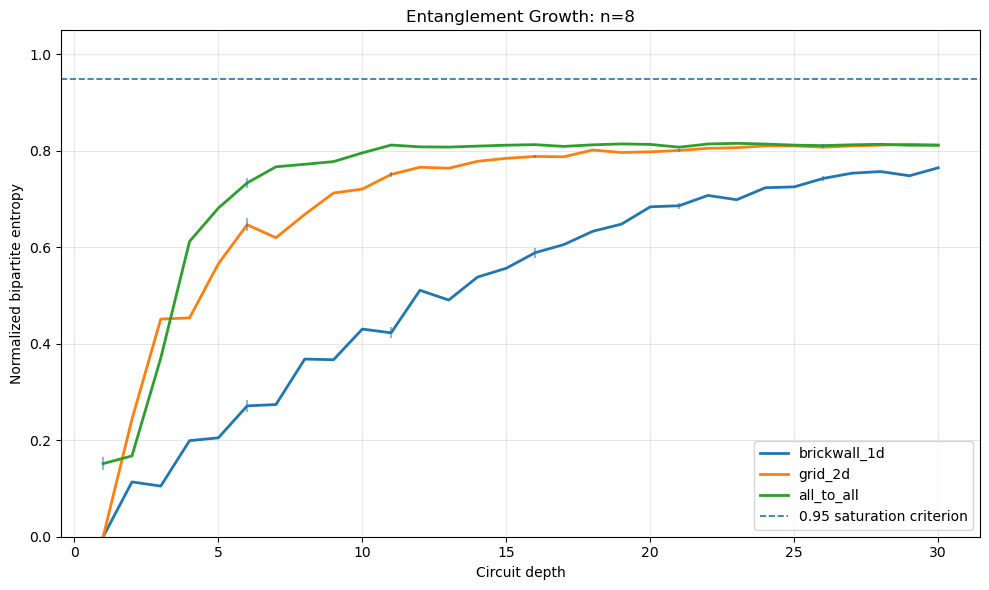

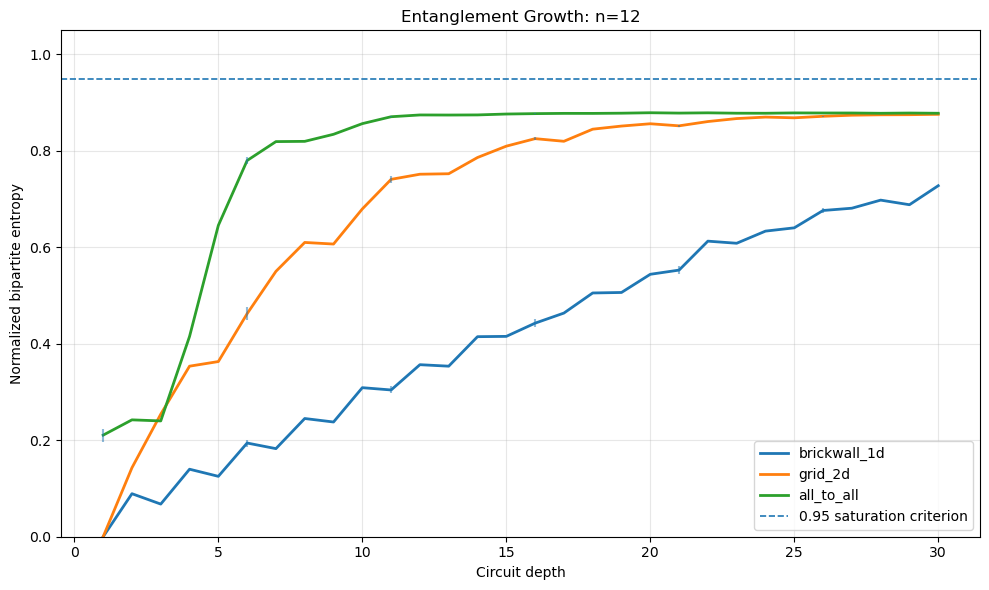

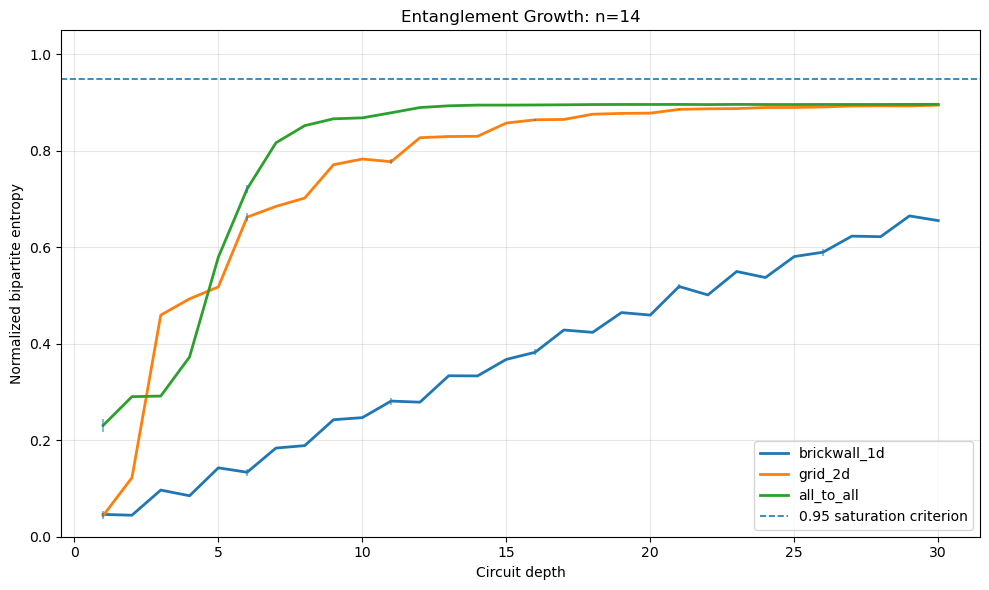

In [32]:
# ============================================================
# CELL 18 — ENTANGLEMENT GROWTH CURVES
# ============================================================

# Representative system sizes.
REPRESENTATIVE_N = [
    8,
    12,
    14,
]

for n in REPRESENTATIVE_N:

    plt.figure(
        figsize=(10, 6)
    )

    for architecture in ARCHITECTURES:

        sub = entropy_raw_df[
            (
                entropy_raw_df[
                    "architecture"
                ]
                == architecture
            )
            &
            (
                entropy_raw_df[
                    "n"
                ] == n
            )
        ].sort_values(
            "depth"
        )

        if len(sub) == 0:
            continue

        plt.plot(
            sub["depth"],
            sub["mean_normalized_entropy"],
            linewidth=2,
            label=architecture
        )

        # Show error bars sparsely to avoid visual clutter.
        sample = sub.iloc[
            ::5
        ]

        plt.errorbar(
            sample["depth"],
            sample["mean_normalized_entropy"],
            yerr=sample[
                "stderr_normalized_entropy"
            ],
            fmt="none",
            alpha=0.5
        )

    plt.axhline(
        SATURATION_LEVEL,
        linestyle="--",
        linewidth=1.2,
        label="0.95 saturation criterion"
    )

    plt.xlabel(
        "Circuit depth"
    )

    plt.ylabel(
        "Normalized bipartite entropy"
    )

    plt.title(
        f"Entanglement Growth: n={n}"
    )

    plt.ylim(
        0,
        1.05
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"entropy_growth_n{n}.png"
        ),
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

---


## Cell 19 — Mark \(\tau_{BP}\) on entropy curves


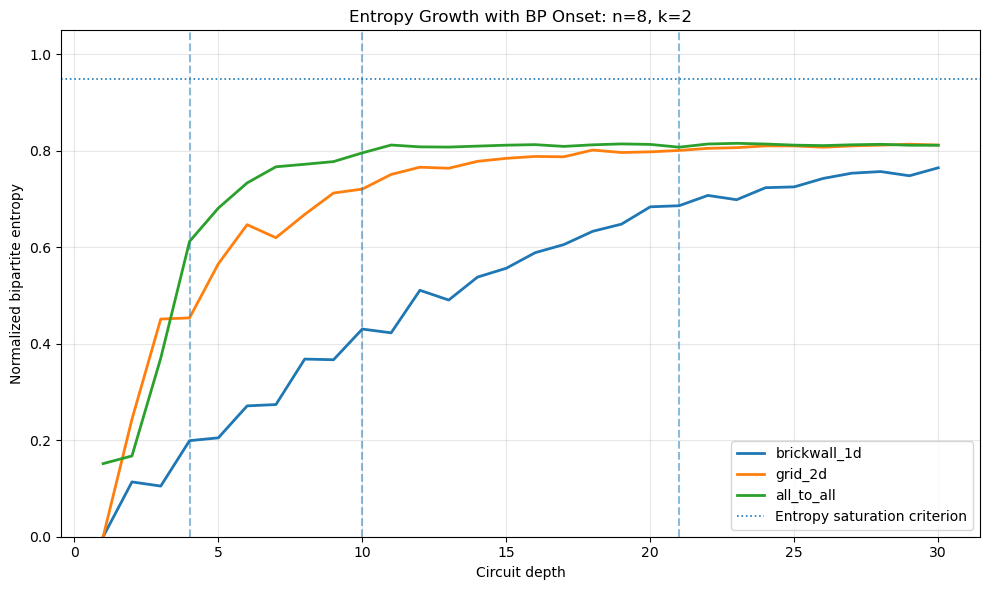

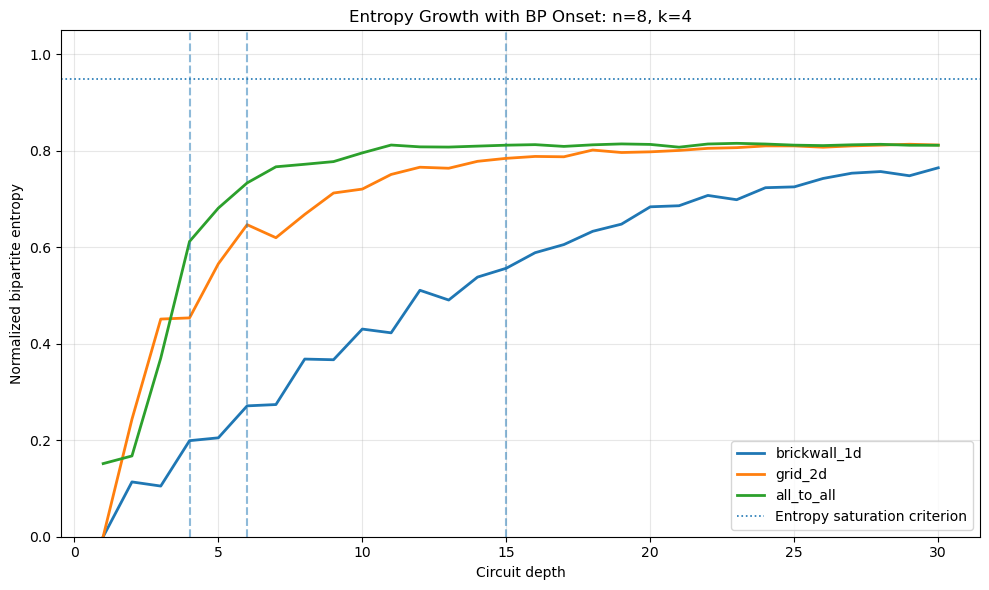

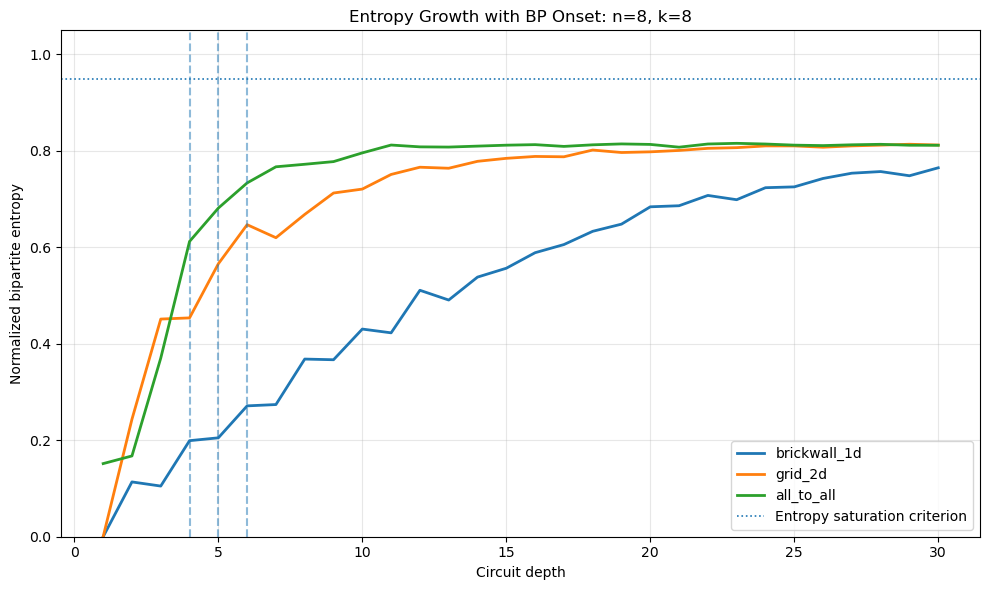

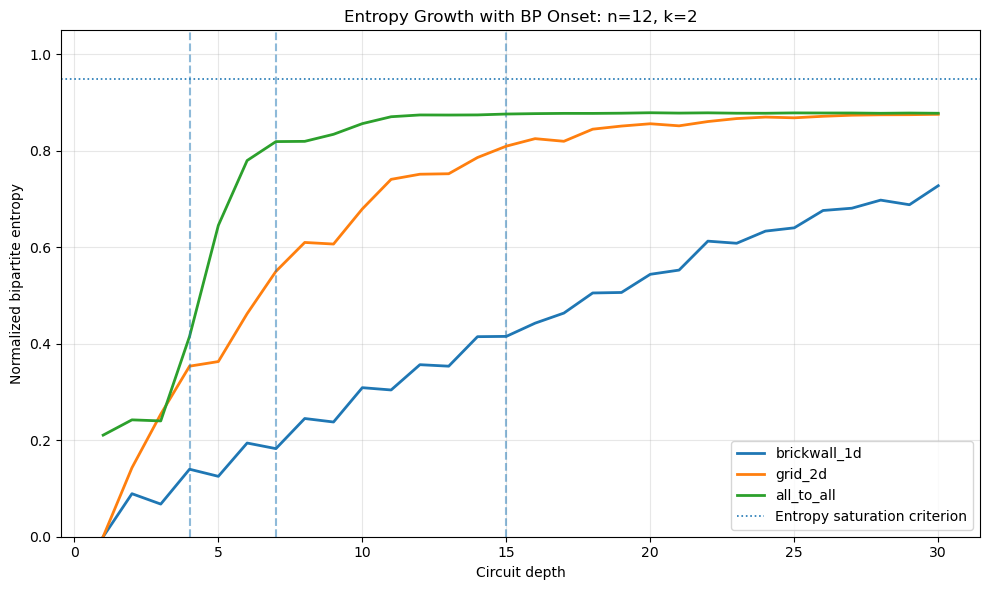

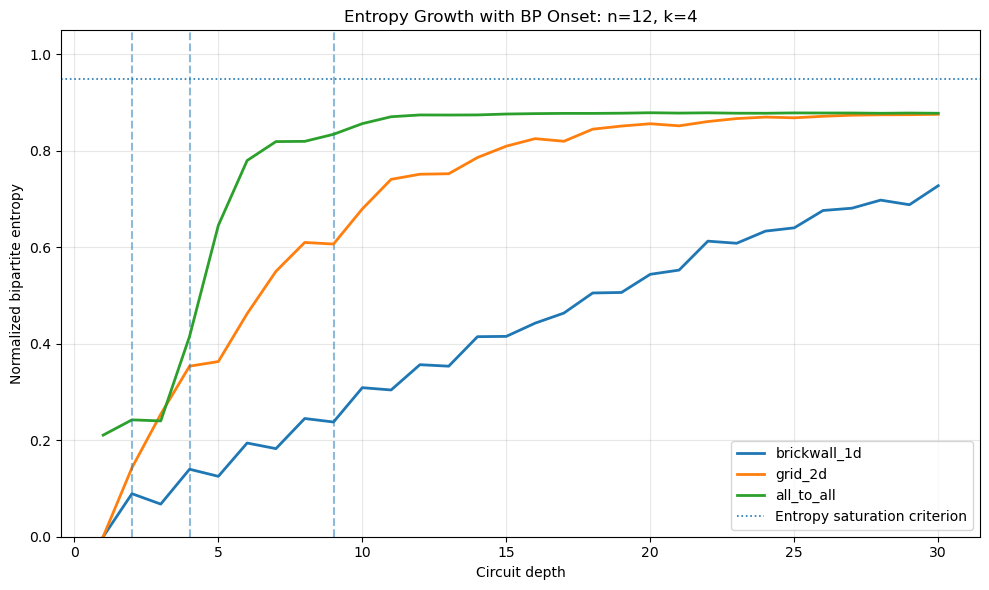

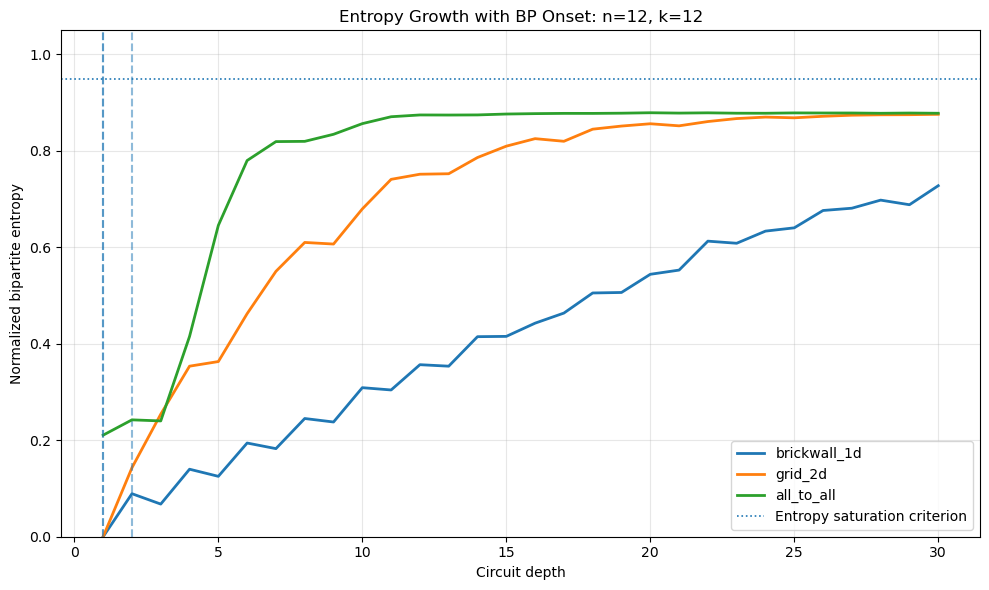

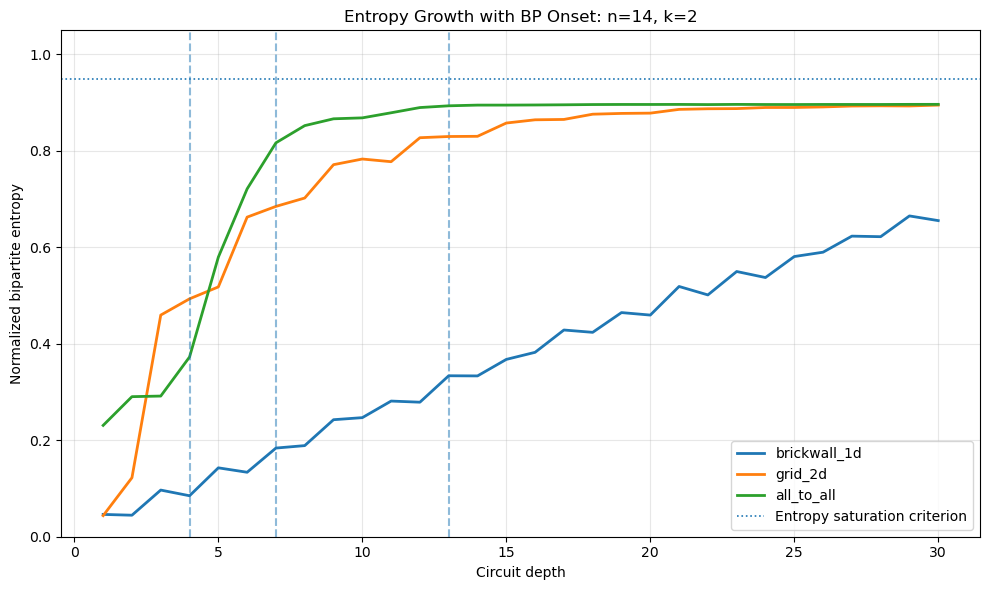

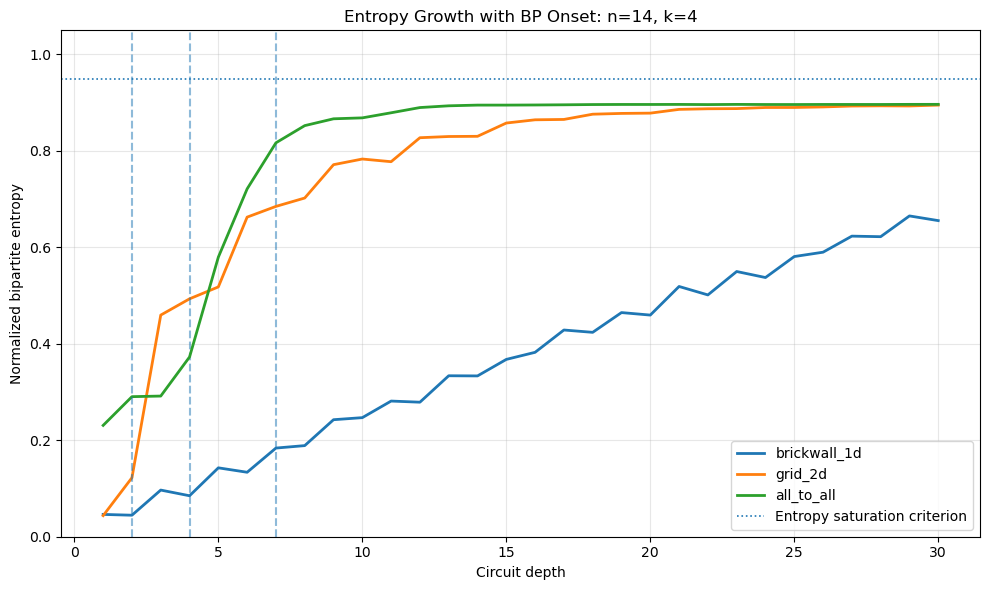

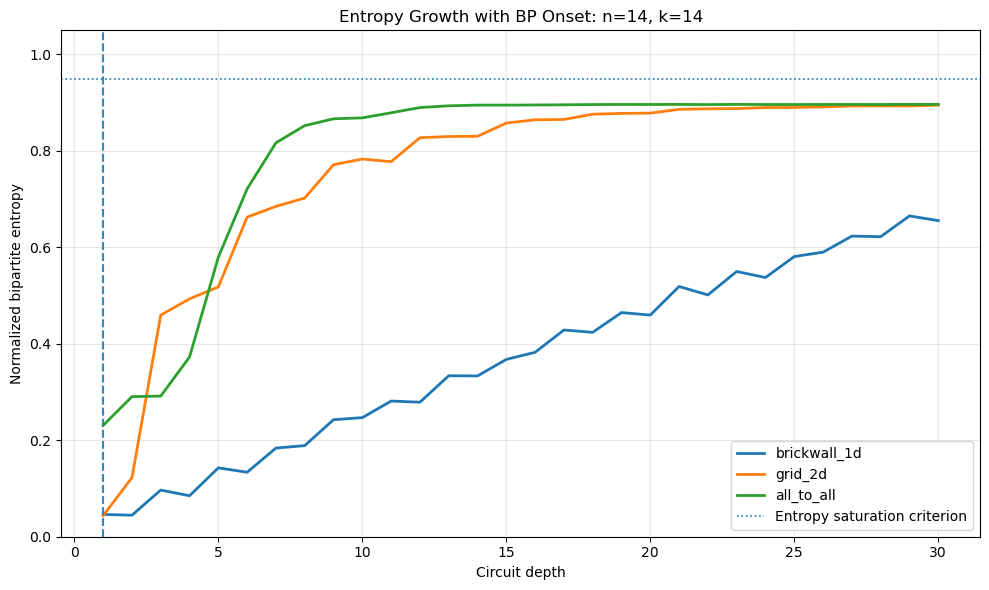

In [33]:
# ============================================================
# CELL 19 — ENTROPY WITH BP ONSET MARKERS
# ============================================================

for n in REPRESENTATIVE_N:

    for k in [
        2,
        min(4, n),
        n,
    ]:

        plt.figure(
            figsize=(10, 6)
        )

        plotted = False

        for architecture in ARCHITECTURES:

            entropy_sub = entropy_raw_df[
                (
                    entropy_raw_df[
                        "architecture"
                    ]
                    == architecture
                )
                &
                (
                    entropy_raw_df[
                        "n"
                    ] == n
                )
            ].sort_values(
                "depth"
            )

            tau_sub = tau_df[
                (
                    tau_df[
                        "architecture"
                    ]
                    == architecture
                )
                &
                (
                    tau_df[
                        "n"
                    ] == n
                )
                &
                (
                    tau_df[
                        "k"
                    ] == k
                )
            ]

            if len(entropy_sub) == 0:
                continue

            plotted = True

            plt.plot(
                entropy_sub["depth"],
                entropy_sub[
                    "mean_normalized_entropy"
                ],
                linewidth=2,
                label=architecture
            )

            if len(tau_sub) == 1:

                tau = int(
                    tau_sub.iloc[0]["tau_BP"]
                )

                plt.axvline(
                    tau,
                    linestyle="--",
                    alpha=0.5
                )

        if not plotted:
            plt.close()
            continue

        plt.axhline(
            SATURATION_LEVEL,
            linestyle=":",
            linewidth=1.2,
            label="Entropy saturation criterion"
        )

        plt.xlabel(
            "Circuit depth"
        )

        plt.ylabel(
            "Normalized bipartite entropy"
        )

        plt.title(
            f"Entropy Growth with BP Onset: n={n}, k={k}"
        )

        plt.ylim(
            0,
            1.05
        )

        plt.grid(
            True,
            alpha=0.3
        )

        plt.legend()

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                OUTPUT_DIR,
                f"entropy_vs_tau_n{n}_k{k}.png"
            ),
            dpi=250,
            bbox_inches="tight"
        )

        plt.show()

---


## Cell 20 — Compare architecture speeds


In [34]:
# ============================================================
# CELL 20 — ENTANGLEMENT SPEED COMPARISON
# ============================================================
#
# Compare the first depth at which normalized entropy reaches:
#
#   0.50
#   0.75
#   0.90
#   0.95
#
# These are descriptive thresholds, not BP definitions.
# ============================================================

ENTROPY_LEVELS = [
    0.50,
    0.75,
    0.90,
    0.95,
]

speed_rows = []

for architecture in ARCHITECTURES:

    for n in N_VALUES:

        sub = entropy_raw_df[
            (
                entropy_raw_df[
                    "architecture"
                ]
                == architecture
            )
            &
            (
                entropy_raw_df[
                    "n"
                ] == n
            )
        ].sort_values(
            "depth"
        )

        for level in ENTROPY_LEVELS:

            crossing = sub[
                sub["mean_normalized_entropy"]
                >= level
            ]

            if len(crossing) > 0:

                depth = int(
                    crossing.iloc[0]["depth"]
                )

            else:

                depth = np.nan

            speed_rows.append({
                "architecture":
                    architecture,

                "n":
                    n,

                "entropy_level":
                    level,

                "depth_to_level":
                    depth,
            })

entropy_speed_df = pd.DataFrame(
    speed_rows
)

print("=" * 80)
print("ENTANGLEMENT GROWTH SPEED")
print("=" * 80)

display(
    entropy_speed_df
)

ENTANGLEMENT GROWTH SPEED


,architecture,n,entropy_level,depth_to_level
0,brickwall_1d,8,0.50,12.0
1,brickwall_1d,8,0.75,27.0
2,brickwall_1d,8,0.90,NaN
3,brickwall_1d,8,0.95,NaN
4,brickwall_1d,10,0.50,15.0
5,brickwall_1d,10,0.75,30.0
6,brickwall_1d,10,0.90,NaN
7,brickwall_1d,10,0.95,NaN
8,brickwall_1d,12,0.50,18.0
9,brickwall_1d,12,0.75,NaN


---


## Cell 21 — Compare entropy speed with BP onset


In [35]:
# ============================================================
# CELL 21 — ENTANGLEMENT SPEED VS BP ONSET
# ============================================================

# Use the 0.95 criterion as one descriptive measure.
speed_95 = entropy_speed_df[
    entropy_speed_df[
        "entropy_level"
    ] == 0.95
][
    [
        "architecture",
        "n",
        "depth_to_level",
    ]
].rename(
    columns={
        "depth_to_level":
            "entropy_depth_95"
    }
)

# Attach this n-level quantity to every k-local tau observation.
tau_speed_df = tau_df.merge(
    speed_95,
    on=[
        "architecture",
        "n",
    ],
    how="left"
)

correlation_rows = []

for architecture in ARCHITECTURES:

    sub = tau_speed_df[
        (
            tau_speed_df[
                "architecture"
            ]
            == architecture
        )
        &
        (
            ~tau_speed_df[
                "censored"
            ]
        )
        &
        (
            tau_speed_df[
                "entropy_depth_95"
            ].notna()
        )
    ]

    if len(sub) >= 3:

        rho, p_value = spearmanr(
            sub["tau_BP"],
            sub["entropy_depth_95"]
        )

    else:

        rho = np.nan
        p_value = np.nan

    correlation_rows.append({
        "architecture":
            architecture,

        "N":
            len(sub),

        "Spearman_tau_vs_entropy_depth_95":
            rho,

        "p_value":
            p_value,
    })

bp_entropy_speed_correlation = pd.DataFrame(
    correlation_rows
)

print("=" * 80)
print("BP ONSET VS ENTANGLEMENT-95% DEPTH")
print("=" * 80)

display(
    bp_entropy_speed_correlation
)

BP ONSET VS ENTANGLEMENT-95% DEPTH


,architecture,N,Spearman_tau_vs_entropy_depth_95,p_value
0,brickwall_1d,0,NaN,NaN
1,grid_2d,0,NaN,NaN
2,all_to_all,0,NaN,NaN


---


## Cell 22 — Final scientific summary


In [36]:
# ============================================================
# CELL 22 — FINAL SCIENTIFIC SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("CHECKPOINT 9 — ENTANGLEMENT-GROWTH ANALYSIS")
print("=" * 90)

print(
    "\nArchitecture-level entanglement summary:"
)

display(
    architecture_entropy_summary
)

print(
    "\nEntropy saturation-depth vs tau_BP:"
)

display(
    entropy_tau_correlation
)

print(
    "\nNormalized entropy at tau_BP vs tau_BP:"
)

display(
    onset_entropy_correlation
)

print(
    "\nBP onset vs entropy-95% depth:"
)

display(
    bp_entropy_speed_correlation
)

print(
    "\nINTERPRETATION RULE"
)

print(
    "This analysis tests whether faster entanglement generation "
    "is associated with earlier BP onset."
)

print(
    "A correlation is evidence of association, not proof that "
    "entanglement growth causes the barren plateau."
)

print(
    "A weak correlation would indicate that entanglement alone "
    "does not explain the architecture-dependent onset."
)

print(
    "Do not claim a universal entropy threshold unless the actual "
    "data demonstrate one."
)


CHECKPOINT 9 — ENTANGLEMENT-GROWTH ANALYSIS

Architecture-level entanglement summary:


,architecture,mean_S_depth30,mean_Snorm_depth30,mean_Snorm_stderr_depth30,median_saturation_depth,mean_saturation_depth
0,all_to_all,4.763134,0.859654,0.000930,NaN,NaN
1,brickwall_1d,3.947490,0.725810,0.005508,NaN,NaN
2,grid_2d,4.755732,0.858465,0.000977,NaN,NaN



Entropy saturation-depth vs tau_BP:


,architecture,N,Spearman_tau_vs_entropy_saturation,p_value
0,brickwall_1d,0,NaN,NaN
1,grid_2d,0,NaN,NaN
2,all_to_all,0,NaN,NaN



Normalized entropy at tau_BP vs tau_BP:


,architecture,N,Spearman_tau_vs_entropy_at_onset,p_value
0,brickwall_1d,30,0.958955,7.335128e-17
1,grid_2d,30,0.965940,5.621410e-18
2,all_to_all,30,0.900417,1.245086e-11



BP onset vs entropy-95% depth:


,architecture,N,Spearman_tau_vs_entropy_depth_95,p_value
0,brickwall_1d,0,NaN,NaN
1,grid_2d,0,NaN,NaN
2,all_to_all,0,NaN,NaN



INTERPRETATION RULE
This analysis tests whether faster entanglement generation is associated with earlier BP onset.
A correlation is evidence of association, not proof that entanglement growth causes the barren plateau.
A weak correlation would indicate that entanglement alone does not explain the architecture-dependent onset.
Do not claim a universal entropy threshold unless the actual data demonstrate one.


---


## Cell 23 — Save publication artifacts


In [37]:
# ============================================================
# CELL 23 — SAVE CHECKPOINT 9
# ============================================================

entropy_raw_df.to_csv(
    RAW_OUTPUT,
    index=False
)

tau_entropy_df.to_csv(
    TAU_ENTANGLEMENT_OUTPUT,
    index=False
)

entropy_saturation_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "entropy_saturation_depth.csv"
    ),
    index=False
)

architecture_entropy_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "architecture_entropy_summary.csv"
    ),
    index=False
)

entropy_tau_correlation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "entropy_tau_correlation.csv"
    ),
    index=False
)

onset_entropy_correlation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "onset_entropy_correlation.csv"
    ),
    index=False
)

entropy_speed_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "entropy_growth_speed.csv"
    ),
    index=False
)

bp_entropy_speed_correlation.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "bp_entropy_speed_correlation.csv"
    ),
    index=False
)

protocol = {
    "checkpoint": 9,

    "experiment":
        "entanglement_growth_analysis",

    "architectures":
        ARCHITECTURES,

    "n_values":
        N_VALUES,

    "k_by_n":
        K_BY_N,

    "n_samples":
        N_SAMPLES,

    "max_depth":
        MAX_DEPTH,

    "simulator":
        SIMULATOR,

    "parameter_distribution":
        "Uniform(0, 2*pi)",

    "ansatz":
        "One RY per qubit followed by architecture-specific "
        "two-qubit matching",

    "bipartition":
        "First floor(n/2) qubits versus remaining qubits",

    "entropy":
        "Von Neumann entropy in bits",

    "normalized_entropy":
        "Entropy divided by maximum bipartite entropy",

    "entropy_saturation_criterion":
        SATURATION_LEVEL,

    "tau_source":
        TAU_FILE,

    "master_seed":
        MASTER_SEED,

    "important":
        "Entropy saturation thresholds are descriptive and "
        "are not used as alternative BP definitions.",
}

with open(
    os.path.join(
        OUTPUT_DIR,
        "checkpoint9_protocol.json"
    ),
    "w"
) as f:

    json.dump(
        protocol,
        f,
        indent=2
    )

print("=" * 80)
print("CHECKPOINT 9 OUTPUTS")
print("=" * 80)

for fname in sorted(
    os.listdir(OUTPUT_DIR)
):

    print(
        os.path.join(
            OUTPUT_DIR,
            fname
        )
    )

print(
    "\nSTATUS: COMPLETE"
)

CHECKPOINT 9 OUTPUTS
notebook9_entanglement_growth\architecture_entropy_summary.csv
notebook9_entanglement_growth\bp_entropy_speed_correlation.csv
notebook9_entanglement_growth\checkpoint9_protocol.json
notebook9_entanglement_growth\checkpoints
notebook9_entanglement_growth\entanglement_raw.csv
notebook9_entanglement_growth\entropy_growth_n12.png
notebook9_entanglement_growth\entropy_growth_n14.png
notebook9_entanglement_growth\entropy_growth_n8.png
notebook9_entanglement_growth\entropy_growth_speed.csv
notebook9_entanglement_growth\entropy_saturation_depth.csv
notebook9_entanglement_growth\entropy_tau_correlation.csv
notebook9_entanglement_growth\entropy_vs_tau_n12_k12.png
notebook9_entanglement_growth\entropy_vs_tau_n12_k2.png
notebook9_entanglement_growth\entropy_vs_tau_n12_k4.png
notebook9_entanglement_growth\entropy_vs_tau_n14_k14.png
notebook9_entanglement_growth\entropy_vs_tau_n14_k2.png
notebook9_entanglement_growth\entropy_vs_tau_n14_k4.png
notebook9_entanglement_growth\entrop

### What matters when you run it

The most useful outputs are **Cell 15, Cell 16, Cell 17, and Cell 22**.

The central question is whether the data support something like:

**faster entanglement growth → earlier \(\tau_{BP}\)**

without us imposing that conclusion beforehand.

Also, this notebook deliberately treats the \(0.95\) entropy level as a **descriptive measurement**, not another definition of a barren plateau. That keeps the original \(10^{-2}\) \(\tau_{BP}\) definition intact.
